Name = Arav Mahind

Roll = 24102A2008

Branch = CMPN-A

Problem Statement: 06

Title: Statistical Analysis of Physical Characteristics of Palmer Penguins.

In [1]:
install.packages(c("palmerpenguins", "dplyr", "ggplot2", "moments", "car", "effsize"))
library(palmerpenguins)
library(dplyr)
library(ggplot2)
library(moments)
library(car)
library(effsize)
cat("Packages loaded successfully.\n")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’


Warning message in install.packages(c("palmerpenguins", "dplyr", "ggplot2", "moments", :
“installation of package ‘ggplot2’ had non-zero exit status”

Attaching package: ‘palmerpenguins’


The following objects are masked from ‘package:datasets’:

    penguins, penguins_raw



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr

Packages loaded successfully.


In [2]:
data("penguins")
head(penguins)
cat("Rows = ", nrow(penguins), "\n")
cat("Columns = ", ncol(penguins), "\n")
str(penguins)
summary(penguins)
colSums(is.na(penguins))

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
Adelie,Torgersen,39.1,18.7,181,3750,male,2007
Adelie,Torgersen,39.5,17.4,186,3800,female,2007
Adelie,Torgersen,40.3,18.0,195,3250,female,2007
Adelie,Torgersen,NA,NA,NA,NA,NA,2007
Adelie,Torgersen,36.7,19.3,193,3450,female,2007
Adelie,Torgersen,39.3,20.6,190,3650,male,2007


Rows =  344 
Columns =  8 
tibble [344 × 8] (S3: tbl_df/tbl/data.frame)
 $ species          : Factor w/ 3 levels "Adelie","Chinstrap",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ island           : Factor w/ 3 levels "Biscoe","Dream",..: 3 3 3 3 3 3 3 3 3 3 ...
 $ bill_length_mm   : num [1:344] 39.1 39.5 40.3 NA 36.7 39.3 38.9 39.2 34.1 42 ...
 $ bill_depth_mm    : num [1:344] 18.7 17.4 18 NA 19.3 20.6 17.8 19.6 18.1 20.2 ...
 $ flipper_length_mm: int [1:344] 181 186 195 NA 193 190 181 195 193 190 ...
 $ body_mass_g      : int [1:344] 3750 3800 3250 NA 3450 3650 3625 4675 3475 4250 ...
 $ sex              : Factor w/ 2 levels "female","male": 2 1 1 NA 1 2 1 2 NA NA ...
 $ year             : int [1:344] 2007 2007 2007 2007 2007 2007 2007 2007 2007 2007 ...


      species          island    bill_length_mm  bill_depth_mm  
 Adelie   :152   Biscoe   :168   Min.   :32.10   Min.   :13.10  
 Chinstrap: 68   Dream    :124   1st Qu.:39.23   1st Qu.:15.60  
 Gentoo   :124   Torgersen: 52   Median :44.45   Median :17.30  
                                 Mean   :43.92   Mean   :17.15  
                                 3rd Qu.:48.50   3rd Qu.:18.70  
                                 Max.   :59.60   Max.   :21.50  
                                 NAs    :2       NAs    :2      
 flipper_length_mm  body_mass_g       sex           year     
 Min.   :172.0     Min.   :2700   female:165   Min.   :2007  
 1st Qu.:190.0     1st Qu.:3550   male  :168   1st Qu.:2007  
 Median :197.0     Median :4050   NAs   : 11   Median :2008  
 Mean   :200.9     Mean   :4202                Mean   :2008  
 3rd Qu.:213.0     3rd Qu.:4750                3rd Qu.:2009  
 Max.   :231.0     Max.   :6300                Max.   :2009  
 NAs    :2         NAs    :2                  

species            island    bill_length_mm     bill_depth_mm 
                0                 0                 2                 2 
flipper_length_mm       body_mass_g               sex              year 
                2                 2                11                 0

Data cleaning


In [3]:
penguins_clean <- penguins %>%
  filter(!is.na(body_mass_g),
         !is.na(flipper_length_mm),
         !is.na(species),
         !is.na(sex)) %>%
  droplevels()

cat("Rows after cleaning process = ", nrow(penguins_clean), "\n")
table(penguins_clean$species)
table(penguins_clean$sex)

Rows after cleaning process =  333 



   Adelie Chinstrap    Gentoo 
      146        68       119 


female   male 
   165    168 

In [4]:
body_mass <- penguins_clean$body_mass_g

descriptive_stats <- data.frame(
  Mean = mean(body_mass),
  Median = median(body_mass),
  Minimum = min(body_mass),
  Maximum = max(body_mass),
  Variance = var(body_mass),
  SD = sd(body_mass),
  Q1 = as.numeric(quantile(body_mass, 0.25)),
  Q3 = as.numeric(quantile(body_mass, 0.75)),
  IQR = IQR(body_mass),
  Skewness = skewness(body_mass),
  Kurtosis = kurtosis(body_mass)
)
descriptive_stats

Mean,Median,Minimum,Maximum,Variance,SD,Q1,Q3,IQR,Skewness,Kurtosis
<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4207.057,4050,2700,6300,648372.5,805.2158,3550,4775,1225,0.4701162,2.259514


In [5]:
species_stats <- penguins_clean %>%
  group_by(species) %>%
  summarise(
    Mean = mean(body_mass_g),
    Median = median(body_mass_g),
    Minimum = min(body_mass_g),
    Maximum = max(body_mass_g),
    Variance = var(body_mass_g),
    SD = sd(body_mass_g),
    Q1 = as.numeric(quantile(body_mass_g, 0.25)),
    Q3 = as.numeric(quantile(body_mass_g, 0.75)),
    IQR = IQR(body_mass_g),
    Skewness = skewness(body_mass_g),
    Kurtosis = kurtosis(body_mass_g),
    .groups = "drop"
  )
species_stats

species,Mean,Median,Minimum,Maximum,Variance,SD,Q1,Q3,IQR,Skewness,Kurtosis
<fct>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Adelie,3706.164,3700,2850,4775,210332.4,458.6201,3362.5,4000,637.5,0.2770077,2.411479
Chinstrap,3733.088,3700,2700,4800,147713.5,384.3351,3487.5,3950,462.5,0.2419413,3.463681
Gentoo,5092.437,5050,3950,6300,251478.3,501.4762,4700.0,5500,800.0,0.0449965,2.242850


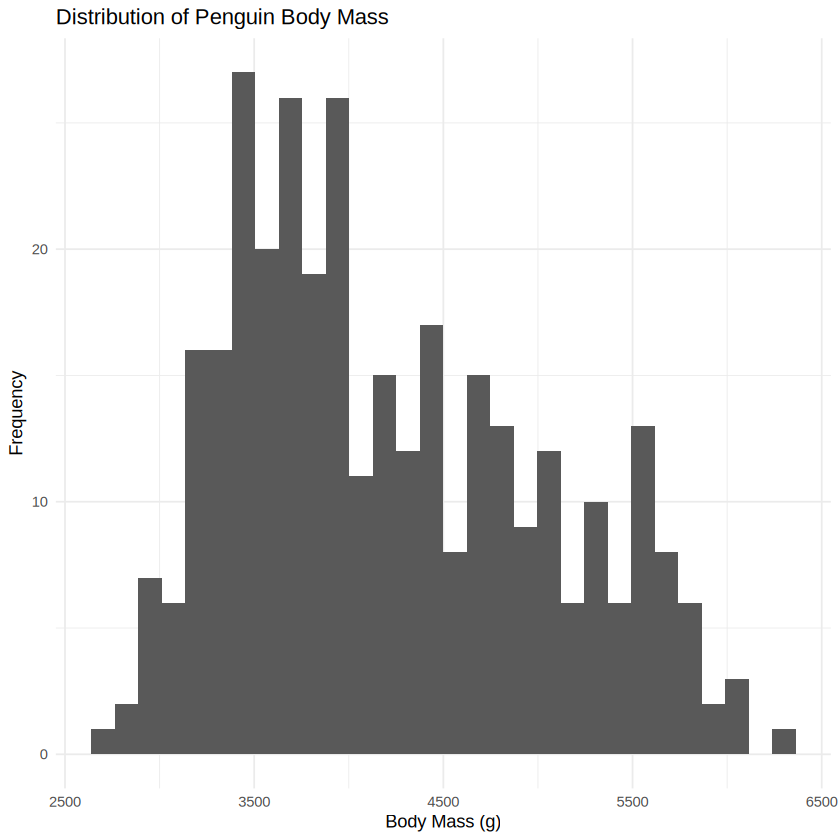

In [6]:
ggplot(penguins_clean, aes(x = body_mass_g)) +
  geom_histogram(bins = 30) +
  labs(title = "Distribution of Penguin Body Mass",
       x = "Body Mass (g)", y = "Frequency") +
  theme_minimal()

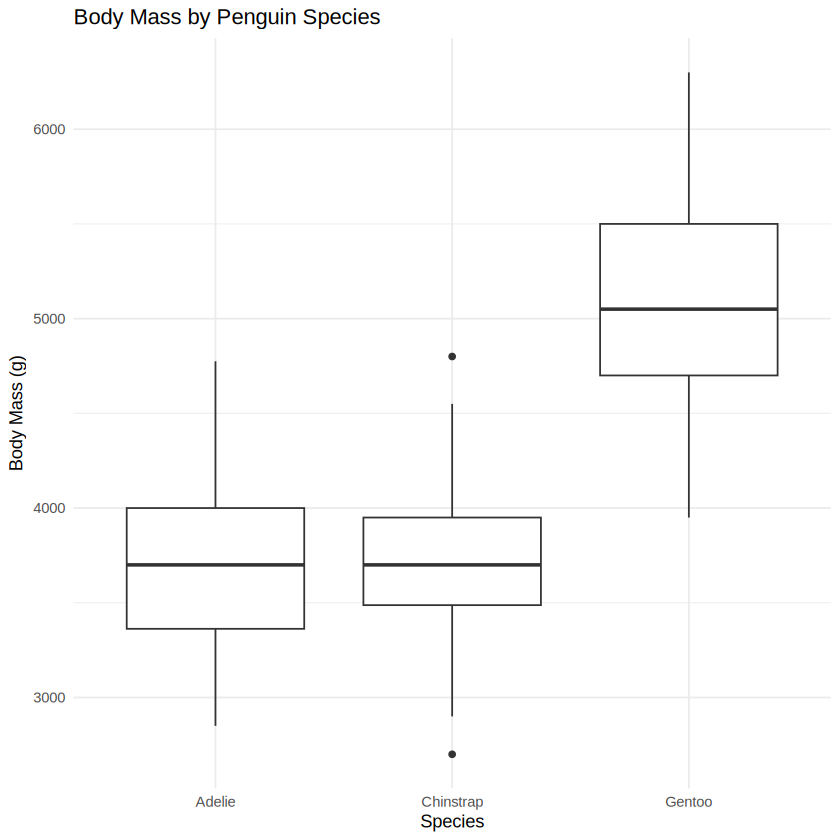

In [7]:
ggplot(penguins_clean, aes(x = species, y = body_mass_g)) +
  geom_boxplot() +
  labs(title = "Body Mass by Penguin Species",
       x = "Species", y = "Body Mass (g)") +
  theme_minimal()

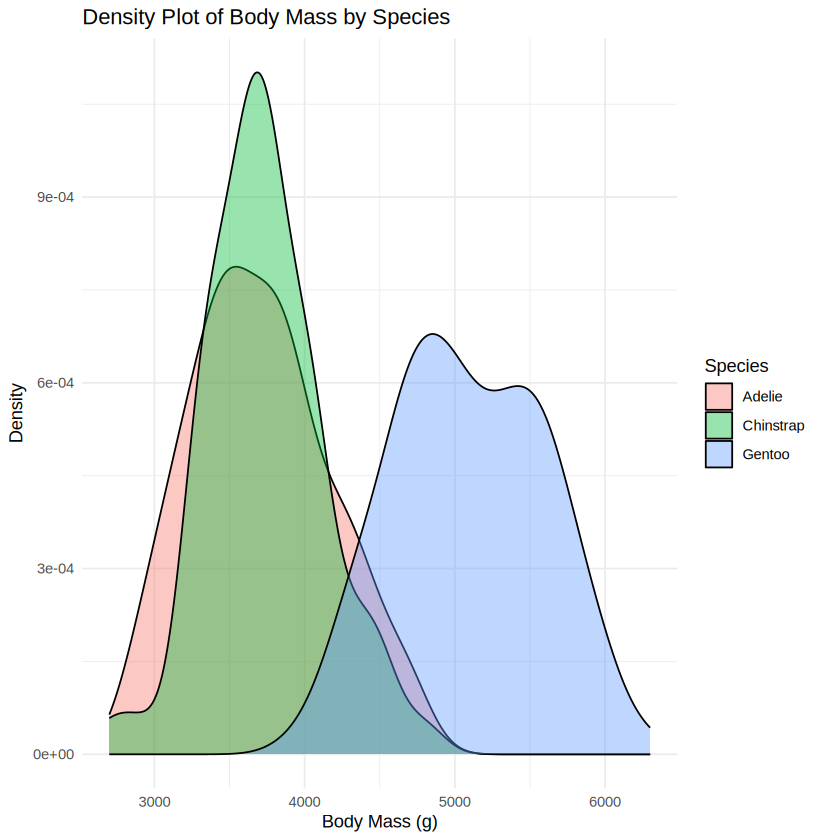

In [8]:
ggplot(penguins_clean, aes(x = body_mass_g, fill = species)) +
  geom_density(alpha = 0.4) +
  labs(title = "Density Plot of Body Mass by Species",
       x = "Body Mass (g)", y = "Density", fill = "Species") +
  theme_minimal()

Hypothesis Testing: Male vs Female Body Mass

**H0:** Male and female penguins have equal mean body mass.

**H1:** Male and female penguins have different mean body mass.

In [9]:
male_mass <- penguins_clean %>% filter(sex == "male") %>% pull(body_mass_g)
female_mass <- penguins_clean %>% filter(sex == "female") %>% pull(body_mass_g)

cat("Male Shapiro-Wilk test = \n")
print(shapiro.test(male_mass))

cat("\nFemale Shapiro-Wilk test = \n")
print(shapiro.test(female_mass))

Male Shapiro-Wilk test = 

	Shapiro-Wilk normality test

data:  male_mass
W = 0.92504, p-value = 1.227e-07


Female Shapiro-Wilk test = 

	Shapiro-Wilk normality test

data:  female_mass
W = 0.91931, p-value = 6.155e-08



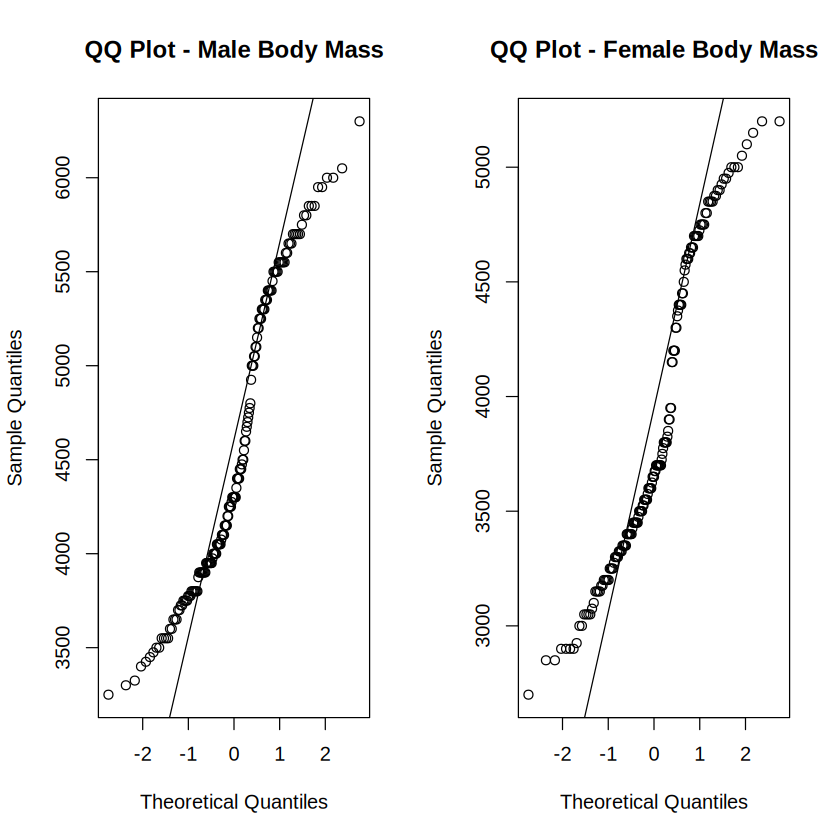

In [10]:
par(mfrow = c(1, 2))
qqnorm(male_mass, main = "QQ Plot - Male Body Mass")
qqline(male_mass)
qqnorm(female_mass, main = "QQ Plot - Female Body Mass")
qqline(female_mass)
par(mfrow = c(1, 1))

In [11]:
t_test_result <- t.test(male_mass, female_mass,
                           var.equal = FALSE, conf.level = 0.95)
t_test_result


	Welch Two Sample t-test

data:  male_mass and female_mass
t = 8.5545, df = 323.9, p-value = 4.794e-16
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 526.2453 840.5783
sample estimates:
mean of x mean of y 
 4545.685  3862.273 


### Cohen's d effect size

In [12]:
cohen_d_result <- cohen.d(male_mass, female_mass,
                              hedges.correction = FALSE)
cohen_d_result


Cohen's d

d estimate: 0.9362048 (large)
95 percent confidence interval:
    lower     upper 
0.7090938 1.1633158 


In [13]:
p_value_t <- t_test_result$p.value
d_value <- as.numeric(cohen_d_result$estimate)

cat("t-test p-value = ", p_value_t, "\n")
cat("95% CI for mean difference = ",
    t_test_result$conf.int[1], "to", t_test_result$conf.int[2], "\n")
cat("Cohen's d = ", d_value, "\n")

if (p_value_t < 0.05) {
  cat("Conclusion= Reject H0; mean body mass differs significantly by sex.\n")
} else {
  cat("Conclusion= Fail to reject H0; insufficient evidence of a difference by sex.\n")
}

t-test p-value =  4.793891e-16 
95% CI for mean difference =  526.2453 to 840.5783 
Cohen's d =  0.9362048 
Conclusion= Reject H0; mean body mass differs significantly by sex.


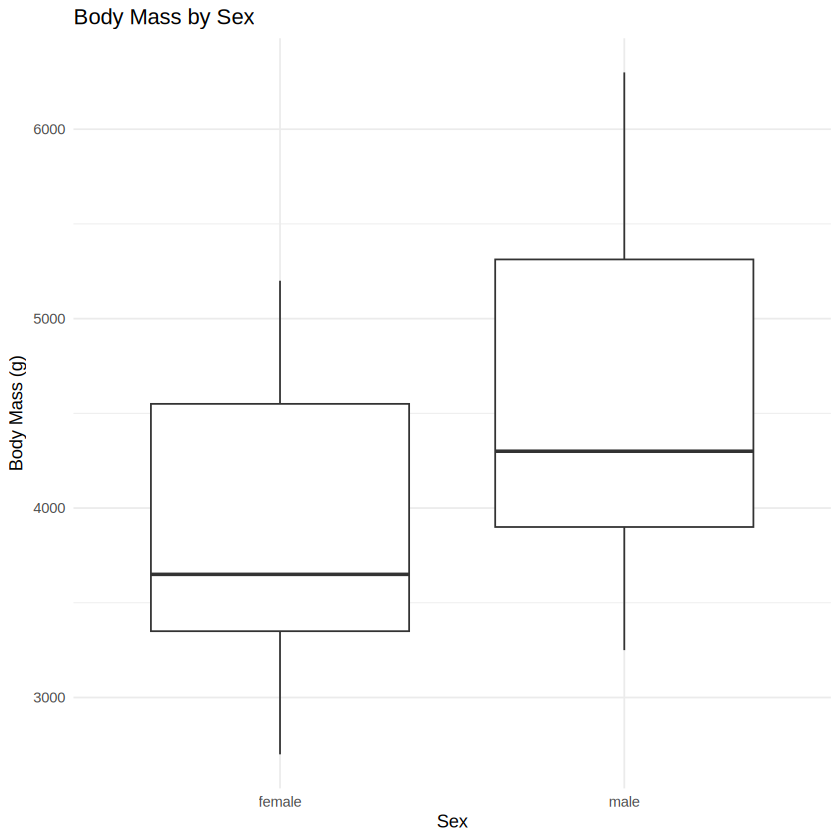

In [14]:
ggplot(penguins_clean, aes(x = sex, y = body_mass_g)) +
  geom_boxplot() +
  labs(title = "Body Mass by Sex",
       x = "Sex", y = "Body Mass (g)") +
  theme_minimal()

One-Way ANOVA: Body Mass by Species

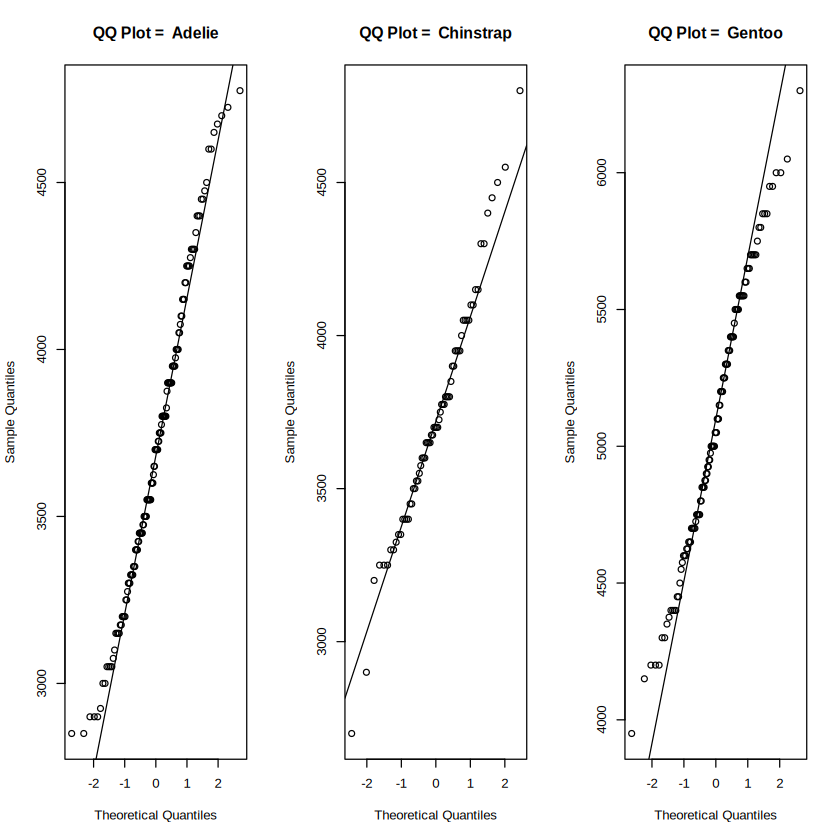

In [15]:
par(mfrow = c(1, 3))
for (sp in levels(penguins_clean$species)) {
  x <- penguins_clean %>% filter(species == sp) %>% pull(body_mass_g)
  qqnorm(x, main = paste("QQ Plot = ", sp))
  qqline(x)
}
par(mfrow = c(1, 1))

In [16]:
shapiro_by_species <- lapply(levels(penguins_clean$species), function(sp) {
  x <- penguins_clean %>% filter(species == sp) %>% pull(body_mass_g)
  result <- shapiro.test(x)
  data.frame(Species = sp, W = unname(result$statistic),
             p_value = result$p.value)
})
do.call(rbind, shapiro_by_species)

Species,W,p_value
<chr>,<dbl>,<dbl>
Adelie,0.9811608,0.0423224
Chinstrap,0.9844938,0.5605082
Gentoo,0.9860612,0.2605247


In [17]:
levene_result <- leveneTest(body_mass_g ~ species, data = penguins_clean)
levene_result

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,5.134899,0.006367054
,330,NA,NA


In [18]:
anova_model <- aov(body_mass_g ~ species, data = penguins_clean)
summary(anova_model)

             Df    Sum Sq  Mean Sq F value Pr(>F)    
species       2 145190219 72595110   341.9 <2e-16 ***
Residuals   330  70069447   212332                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Tukey HSD post-hoc analysis

In [19]:
tukey_result <- TukeyHSD(anova_model)
tukey_result

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = body_mass_g ~ species, data = penguins_clean)

$species
                       diff       lwr       upr    p adj
Chinstrap-Adelie   26.92385 -132.3528  186.2005 0.916431
Gentoo-Adelie    1386.27259 1252.2897 1520.2554 0.000000
Gentoo-Chinstrap 1359.34874 1194.4304 1524.2671 0.000000


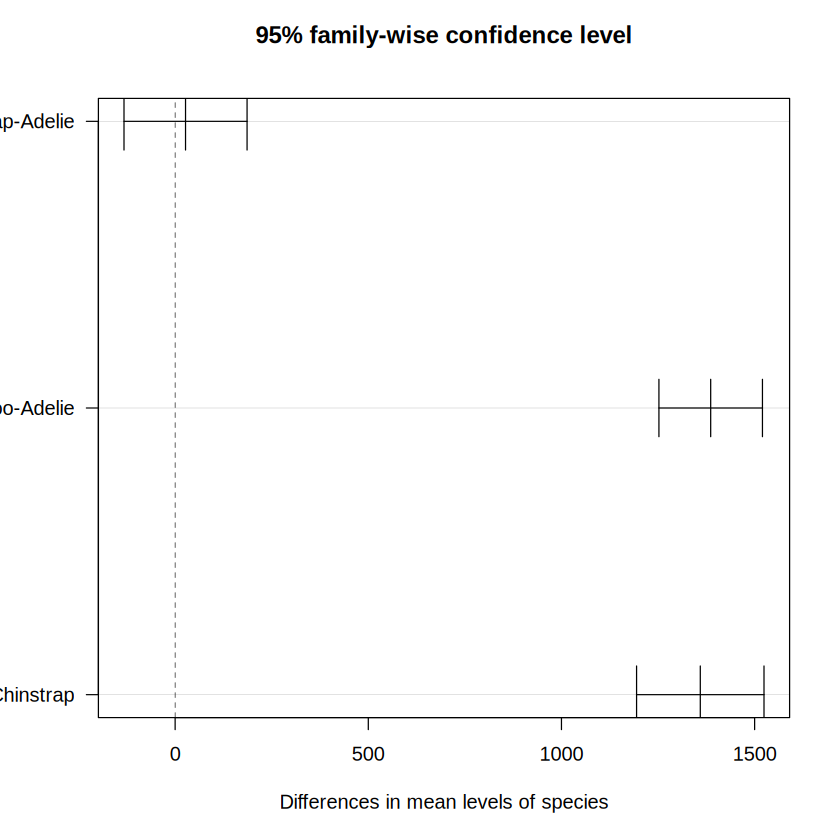

In [20]:
plot(tukey_result, las = 1)

Kruskal-Wallis Non-Parametric Test

In [21]:
kruskal_result <- kruskal.test(body_mass_g ~ species, data = penguins_clean)
kruskal_result


	Kruskal-Wallis rank sum test

data:  body_mass_g by species
Kruskal-Wallis chi-squared = 212.09, df = 2, p-value < 2.2e-16


In [22]:
anova_p <- summary(anova_model)[[1]][["Pr(>F)"]][1]
kw_p <- kruskal_result$p.value

cat("ANOVA p-value:", anova_p, "\n")
cat("Kruskal-Wallis p-value:", kw_p, "\n")

if (anova_p < 0.05 && kw_p < 0.05) {
  cat("Both methods indicate significant differences among species.\n")
} else if (anova_p >= 0.05 && kw_p >= 0.05) {
  cat("Both methods indicate no significant differences among species.\n")
} else {
  cat("The methods differ; examine assumptions and distributions carefully.\n")
}

ANOVA p-value: 3.744505e-81 
Kruskal-Wallis p-value: 8.836877e-47 
Both methods indicate significant differences among species.


Two-Way ANOVA: Species and Sex

Model: `body_mass_g ~ species * sex`

This evaluates species, sex, and their interaction.

In [23]:
two_way_model <- aov(body_mass_g ~ species * sex, data = penguins_clean)
summary(two_way_model)

             Df    Sum Sq  Mean Sq F value   Pr(>F)    
species       2 145190219 72595110 758.358  < 2e-16 ***
sex           1  37090262 37090262 387.460  < 2e-16 ***
species:sex   2   1676557   838278   8.757 0.000197 ***
Residuals   327  31302628    95727                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

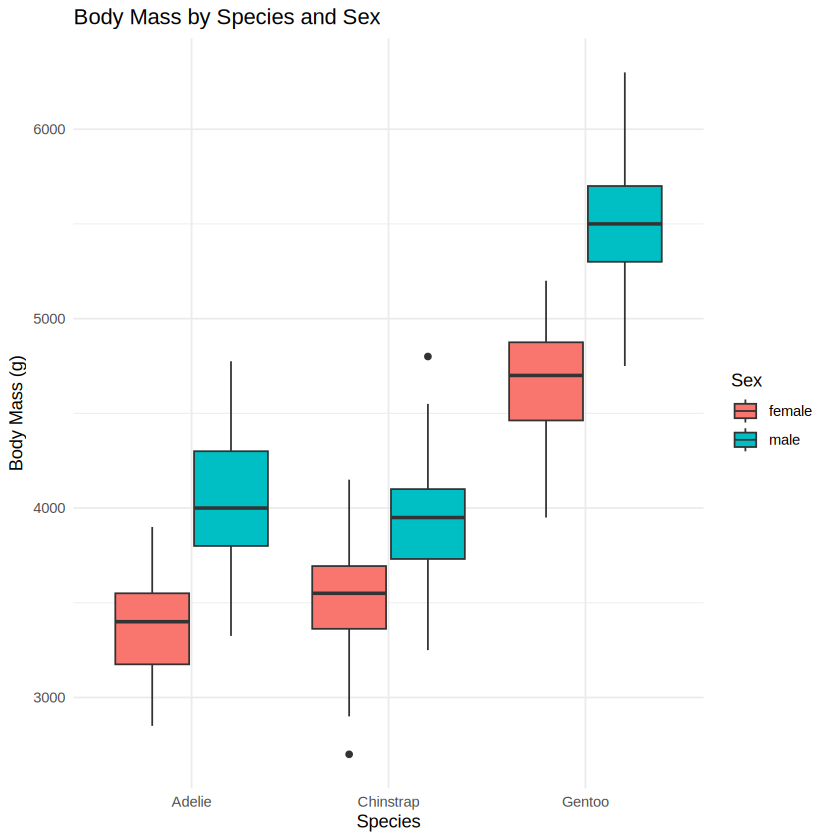

In [24]:
ggplot(penguins_clean, aes(x = species, y = body_mass_g, fill = sex)) +
  geom_boxplot(position = position_dodge(width = 0.8)) +
  labs(title = "Body Mass by Species and Sex",
       x = "Species", y = "Body Mass (g)", fill = "Sex") +
  theme_minimal()

Additional Analysis: Flipper Length

In [25]:
flipper_stats <- penguins_clean %>%
  group_by(species) %>%
  summarise(
    Mean = mean(flipper_length_mm),
    Median = median(flipper_length_mm),
    SD = sd(flipper_length_mm),
    Minimum = min(flipper_length_mm),
    Maximum = max(flipper_length_mm),
    IQR = IQR(flipper_length_mm),
    .groups = "drop"
  )
flipper_stats

species,Mean,Median,SD,Minimum,Maximum,IQR
<fct>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>
Adelie,190.1027,190,6.521825,172,210,9.0
Chinstrap,195.8235,196,7.131894,178,212,10.0
Gentoo,217.2353,216,6.585431,203,231,9.5


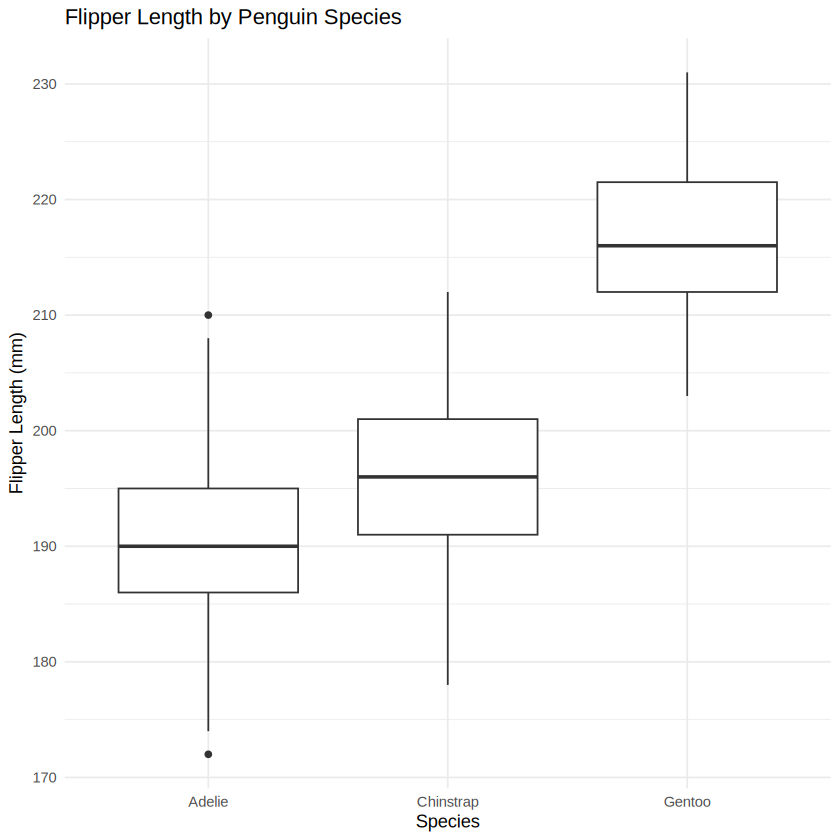

In [26]:
ggplot(penguins_clean, aes(x = species, y = flipper_length_mm)) +
  geom_boxplot() +
  labs(title = "Flipper Length by Penguin Species",
       x = "Species", y = "Flipper Length (mm)") +
  theme_minimal()

In [27]:
flipper_anova <- aov(flipper_length_mm ~ species, data = penguins_clean)
summary(flipper_anova)

             Df Sum Sq Mean Sq F value Pr(>F)    
species       2  50526   25263   567.4 <2e-16 ***
Residuals   330  14693      45                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [28]:
TukeyHSD(flipper_anova)

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = flipper_length_mm ~ species, data = penguins_clean)

$species
                     diff       lwr       upr p adj
Chinstrap-Adelie  5.72079  3.414364  8.027215     0
Gentoo-Adelie    27.13255 25.192399 29.072709     0
Gentoo-Chinstrap 21.41176 19.023644 23.799885     0


In [29]:
flipper_kw <- kruskal.test(flipper_length_mm ~ species,
                               data = penguins_clean)
flipper_kw


	Kruskal-Wallis rank sum test

data:  flipper_length_mm by species
Kruskal-Wallis chi-squared = 237.35, df = 2, p-value < 2.2e-16


Group Comparison Plot

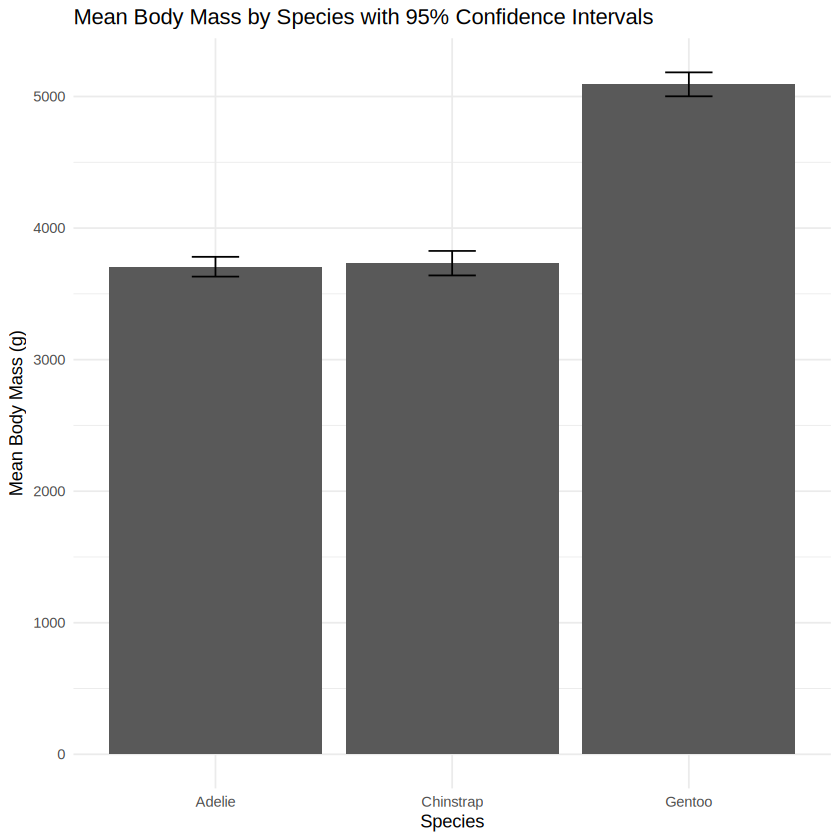

In [30]:
body_mass_summary <- penguins_clean %>%
  group_by(species) %>%
  summarise(
    mean_mass = mean(body_mass_g),
    sd_mass = sd(body_mass_g),
    n = n(),
    se = sd_mass / sqrt(n),
    lower = mean_mass - qt(0.975, df = n - 1) * se,
    upper = mean_mass + qt(0.975, df = n - 1) * se,
    .groups = "drop"
  )

ggplot(body_mass_summary, aes(x = species, y = mean_mass)) +
  geom_col() +
  geom_errorbar(aes(ymin = lower, ymax = upper), width = 0.2) +
  labs(title = "Mean Body Mass by Species with 95% Confidence Intervals",
       x = "Species", y = "Mean Body Mass (g)") +
  theme_minimal()

In [31]:
anova_table <- summary(anova_model)[[1]]

cat("======= FINAL SUMMARY =======\n")
cat("Cleaned observations:", nrow(penguins_clean), "\n\n")

cat("Male vs Female t-test\n")
cat("t =", unname(t_test_result$statistic), "\n")
cat("p-value =", t_test_result$p.value, "\n")
cat("95% CI =", t_test_result$conf.int[1], "to", t_test_result$conf.int[2], "\n")
cat("Cohen's d =", d_value, "\n\n")

cat("One-way ANOVA: Body Mass ~ Species\n")
cat("F =", anova_table$`F value`[1], "\n")
cat("p-value =", anova_table$`Pr(>F)`[1], "\n\n")

cat("Kruskal-Wallis: Body Mass ~ Species\n")
cat("Chi-squared =", unname(kruskal_result$statistic), "\n")
cat("p-value =", kruskal_result$p.value, "\n\n")

cat("Two-way ANOVA: Species * Sex\n")
print(summary(two_way_model))

cat("\nFlipper length ANOVA\n")
print(summary(flipper_anova))

========== FINAL SUMMARY ==========
Cleaned observations: 333 

Male vs Female t-test
t = 8.554537 
p-value = 4.793891e-16 
95% CI = 526.2453 to 840.5783 
Cohen's d = 0.9362048 

One-way ANOVA: Body Mass ~ Species
F = 341.8949 
p-value = 3.744505e-81 

Kruskal-Wallis: Body Mass ~ Species
Chi-squared = 212.0851 
p-value = 8.836877e-47 

Two-way ANOVA: Species * Sex
             Df    Sum Sq  Mean Sq F value   Pr(>F)    
species       2 145190219 72595110 758.358  < 2e-16 ***
sex           1  37090262 37090262 387.460  < 2e-16 ***
species:sex   2   1676557   838278   8.757 0.000197 ***
Residuals   327  31302628    95727                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Flipper length ANOVA
             Df Sum Sq Mean Sq F value Pr(>F)    
species       2  50526   25263   567.4 <2e-16 ***
Residuals   330  14693      45                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


### **Conclusion**

The results indicate that body mass varies significantly across both sex and penguin species (p < 0.001). A strong difference between sexes was also observed, with a Cohen’s d of 0.936. Both One-way ANOVA and Kruskal-Wallis tests produced similar findings. The Two-way ANOVA further showed that species, sex, and their interaction significantly affect body mass. Flipper length also showed significant differences between species (p < 0.001).

Overall, the findings suggest that both species and sex have a significant impact on the physical characteristics of penguins.
